# PREPARATION

## Imports and Data Loading

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_dataset.csv') # this is for pahse 3 and phase 4, instaead of do phase 4 with raw dataset i use this

## Bunch of helper functions, used for data cleaning

In [3]:
# Helper functions

def missing_info(df):
    missing_info = pd.DataFrame({
        'Missing Count': df.isna().sum(),
        'Percent': (df.isna().mean() * 100).round(2),
        'Data type': df.dtypes,
    })
    
    missing_info = missing_info[missing_info['Missing Count'] > 0]
    return missing_info.sort_values('Percent',ascending=False)

def is_duplicates(df):
    print(f'Total Duplicates: {df.duplicated().sum()}')

def clean_rent(df):
    # Remove missing rent values
    df = df.dropna(subset=['rent'])

    # Remove unrealistic rent values
    df = df[df['rent'] >= 1000]

    print("Missing Values in Rent:")
    print(missing_info(df[['rent']]))

    print(f"Rent below 1000: {(df['rent'] < 1000).sum()}")

    return df

def drop_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:

    df = df.drop(columns=columns)
    return df

def drop_duplicates(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:

    df = df.drop_duplicates(subset=columns)
    is_duplicates(df)
    return df

def drop_nan_rows(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:

    df = df.dropna(subset=columns)
    print(f'Missg Values: {missing_info(df)}')
    return df

def transit_imputation(df: pd.DataFrame) -> pd.DataFrame:

    print(f'Before Imputations:\nmissing values:{missing_info(df[['transit_score']])}')
    print()
    # this is for fix the left influend skew-ness (should be done before imputation)
    df['transit_score'] = df['transit_score'].replace(-10, np.nan)

    # creating tag for msiing values rows
    df['transit_score_missing'] = df['transit_score'].isna().astype(int)

    # impute with local (locality) median
    df['transit_score'] = (
         
         df.groupby('locality')['transit_score']
        .transform(lambda x: x.fillna(x.median()))
    )

    # impute with global median (if local median is Nan)
    df['transit_score'] = df['transit_score'].fillna(df['transit_score'].median())

    print(f'After Imputation:\nMissing Values {missing_info(df[["transit_score"]])}')
    return df

def lifestyle_imputation(df: pd.DataFrame) -> pd.DataFrame:
        
        # creating tag for msiing values rows
        df['lifestylet_score_missing'] = df['lifestyle_score'].isna().astype(int)
    
        # impute with local (locality) median
        df['lifestyle_score'] = (
             df.groupby('locality')['lifestyle_score']
             .transform(lambda x: x.fillna(x.median()))
        )
    
        # impute with global median (if local median is Nan)
        df['lifestyle_score'] = df['lifestyle_score'].fillna(df['lifestyle_score'].median())
    
        print(f'After Imputation:\nMissing Values {missing_info(df[["lifestyle_score"]])}')
        return df

def change_obj_bool(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
     bool_col = columns
     df[bool_col] = df[bool_col].astype('bool')
     return df

def impute_rows_as_false(df: pd.DataFrame, rows: list[str]) -> pd.DataFrame:
     rows = rows
     df[rows] = df[rows].fillna(False)
     return df

def impute_rows_as_none(df: pd.DataFrame, rows: list[str]) -> pd.DataFrame:
     df[rows] = df[rows].fillna('None')
     return df

def one_hot_encoding(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
     df = pd.get_dummies(
          data = df,
          columns = columns,
          drop_first = True,
          dtype = 'int8',
     )

     return df

# Data Cleaning

## Checklist

based on the EDA observations

1.  drop_duplicates(subset=['id', 'occupancy'])
2.  Drop rent <= 1000 rows
3.  Drop rent NaN rows
4.  Drop occupancy NaN rows (24 rows)
5.  Replace transit_score == -10 → NaN
6.  Create has_location_scores (before imputation)
7.  Change True/False object → bool
8.  Fill amenity NaNs → False
9.  Impute transit_score / lifestyle_score (locality median → global median)
10. Drop columns: id, title, address, gate_closing_time, total_bathrooms
11. Encode: gender, available_for, occupancy, parking (OHE)
12. Encode: locality (decide: OHE vs target encoding)
13. log1p transform: rent, deposit
14. Train/test split (before any fit-based encoding)
15. Final checks

In [4]:
# 1. drop duplicates

df = drop_duplicates(df, columns=['id', 'occupancy'])

Total Duplicates: 0


In [5]:
# 2. Remobve Rent rows which has Nan Values
# 2.1 . Remove rent Values ranged (rent = 0 - 1000)
df = clean_rent(df)

Missing Values in Rent:
Empty DataFrame
Columns: [Missing Count, Percent, Data type]
Index: []
Rent below 1000: 0


In [6]:
missing_info(df)

,Missing Count,Percent,Data type
gate_closing_time,1240,84.30,str
lifestyle_score,761,51.73,float64
transit_score,761,51.73,float64
mess,746,50.71,object
cooking_allowed,745,50.65,object
power_backup,742,50.44,object
wifi,742,50.44,object
common_tv,741,50.37,object
refrigerator,741,50.37,object
room_cleaning,725,49.29,object


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1782
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1471 non-null   str    
 1   title               1471 non-null   str    
 2   latitude            1471 non-null   float64
 3   longitude           1471 non-null   float64
 4   locality            1471 non-null   str    
 5   address             1471 non-null   str    
 6   gender              1471 non-null   str    
 7   available_for       1471 non-null   str    
 8   transit_score       710 non-null    float64
 9   lifestyle_score     710 non-null    float64
 10  occupancy           1471 non-null   str    
 11  rent                1471 non-null   float64
 12  deposit             1471 non-null   float64
 13  attached_bathroom   1471 non-null   object 
 14  food_included       1471 non-null   bool   
 15  breakfast           1471 non-null   bool   
 16  lunch               14

In [8]:
# 3. droping rows which has ~1% of missing values
# so the ~1% missing colums are deoped when we droped the rent row so thwy are all has same missing rows (24 rowa)
# so here i derop the useless columsn then

# drop_nan_rows(df, columns=['gate_closing_time'])
col = ['id', 'title', 'address', 'total_bathrooms', 'warden', 'cooking_allowed', 'gate_closing_time', 'guardian_required', 'nonveg_allowed', 'smoking_allowed']
df = drop_columns(df, columns=col)

In [9]:
# 4. imputations

# transit & lifestyle imputation
transit_imputation(df)
lifestyle_imputation(df)

Before Imputations:
missing values:               Missing Count  Percent Data type
transit_score            761    51.73   float64

After Imputation:
Missing Values Empty DataFrame
Columns: [Missing Count, Percent, Data type]
Index: []
After Imputation:
Missing Values Empty DataFrame
Columns: [Missing Count, Percent, Data type]
Index: []


,latitude,longitude,locality,gender,available_for,transit_score,lifestyle_score,occupancy,rent,deposit,...,room_cleaning,parking,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,transit_score_missing,lifestylet_score_missing
0,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,SINGLE,14000.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
1,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,DOUBLE,10500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
2,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,THREE,8500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
3,12.905105,80.095660,Perungalathur,MALE,Both,6.3,4.1,FOUR,4000.0,2000.0,...,NaN,Bike,False,False,False,False,False,False,1,1
4,12.918673,80.081292,Shanthi Nagar,MALE,Both,5.9,9.1,THREE,7500.0,1000.0,...,NaN,Bike,False,False,False,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1778,13.052887,80.213536,Vadapalani,FEMALE,Both,8.2,6.2,FOUR,8000.0,8000.0,...,False,Bike,False,False,False,False,False,False,1,1
1779,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,SINGLE,13000.0,28000.0,...,True,Bike,True,True,False,True,True,True,1,1
1780,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,DOUBLE,13500.0,27000.0,...,True,Bike,True,True,False,True,True,True,1,1
1781,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,THREE,9000.0,18000.0,...,True,Bike,True,True,False,True,True,True,1,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1782
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   latitude                  1471 non-null   float64
 1   longitude                 1471 non-null   float64
 2   locality                  1471 non-null   str    
 3   gender                    1471 non-null   str    
 4   available_for             1471 non-null   str    
 5   transit_score             1471 non-null   float64
 6   lifestyle_score           1471 non-null   float64
 7   occupancy                 1471 non-null   str    
 8   rent                      1471 non-null   float64
 9   deposit                   1471 non-null   float64
 10  attached_bathroom         1471 non-null   object 
 11  food_included             1471 non-null   bool   
 12  breakfast                 1471 non-null   bool   
 13  lunch                     1471 non-null   bool   
 14  dinner                  

In [11]:
# 5. impute amenites

# before imputing amenities we need to change the data types
bool_cols = [
    'attached_bathroom', 'mess', 'wifi', 'laundry', 'power_backup',
    'refrigerator', 'common_tv', 'room_cleaning','room_ac', 
    'room_cupboard', 'room_tv', 'room_geyser', 'room_bedding',
    'room_attached_bath',
]
change_obj_bool(df, columns=bool_cols)

,latitude,longitude,locality,gender,available_for,transit_score,lifestyle_score,occupancy,rent,deposit,...,room_cleaning,parking,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,transit_score_missing,lifestylet_score_missing
0,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,SINGLE,14000.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
1,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,DOUBLE,10500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
2,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,THREE,8500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
3,12.905105,80.095660,Perungalathur,MALE,Both,6.3,4.1,FOUR,4000.0,2000.0,...,True,Bike,False,False,False,False,False,False,1,1
4,12.918673,80.081292,Shanthi Nagar,MALE,Both,5.9,9.1,THREE,7500.0,1000.0,...,True,Bike,False,False,False,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1778,13.052887,80.213536,Vadapalani,FEMALE,Both,8.2,6.2,FOUR,8000.0,8000.0,...,False,Bike,False,False,False,False,False,False,1,1
1779,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,SINGLE,13000.0,28000.0,...,True,Bike,True,True,False,True,True,True,1,1
1780,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,DOUBLE,13500.0,27000.0,...,True,Bike,True,True,False,True,True,True,1,1
1781,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,THREE,9000.0,18000.0,...,True,Bike,True,True,False,True,True,True,1,1


In [12]:
impute_rows_as_false(df, bool_cols)
impute_rows_as_none(df, rows=['parking'])

,latitude,longitude,locality,gender,available_for,transit_score,lifestyle_score,occupancy,rent,deposit,...,room_cleaning,parking,room_ac,room_cupboard,room_tv,room_geyser,room_bedding,room_attached_bath,transit_score_missing,lifestylet_score_missing
0,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,SINGLE,14000.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
1,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,DOUBLE,10500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
2,12.892600,80.114600,Perungalathur,MALE,Both,5.7,4.1,THREE,8500.0,10000.0,...,True,Car,True,True,True,True,True,True,0,0
3,12.905105,80.095660,Perungalathur,MALE,Both,6.3,4.1,FOUR,4000.0,2000.0,...,True,Bike,False,False,False,False,False,False,1,1
4,12.918673,80.081292,Shanthi Nagar,MALE,Both,5.9,9.1,THREE,7500.0,1000.0,...,True,Bike,False,False,False,False,False,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1778,13.052887,80.213536,Vadapalani,FEMALE,Both,8.2,6.2,FOUR,8000.0,8000.0,...,False,Bike,False,False,False,False,False,False,1,1
1779,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,SINGLE,13000.0,28000.0,...,True,Bike,True,True,False,True,True,True,1,1
1780,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,DOUBLE,13500.0,27000.0,...,True,Bike,True,True,False,True,True,True,1,1
1781,13.049665,80.227043,Kodambakkam,FEMALE,Working Professional,7.8,6.3,THREE,9000.0,18000.0,...,True,Bike,True,True,False,True,True,True,1,1


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 1471 entries, 0 to 1782
Data columns (total 37 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   latitude                            1471 non-null   float64
 1   longitude                           1471 non-null   float64
 2   locality                            1471 non-null   str    
 3   transit_score                       1471 non-null   float64
 4   lifestyle_score                     1471 non-null   float64
 5   rent                                1471 non-null   float64
 6   deposit                             1471 non-null   float64
 7   attached_bathroom                   1471 non-null   bool   
 8   food_included                       1471 non-null   bool   
 9   breakfast                           1471 non-null   bool   
 10  lunch                               1471 non-null   bool   
 11  dinner                              1471 non-null   bool   

In [20]:
# 6. Encoding

ohe_col = ['gender', 'available_for', 'occupancy', 'parking']
df = one_hot_encoding(df, columns=ohe_col)

In [22]:
df[['rent', 'deposit']].skew()

rent        4.924614
deposit    10.841171
dtype: float64

In [23]:
import numpy as np

def log_transform(df, columns: list[str]) -> pd.DataFrame:
    df[columns] = np.log1p(df[columns])
    return df

In [24]:
col = ['rent', 'deposit']

df = log_transform(df, columns=col)

In [25]:
df[['rent', 'deposit']].skew()

rent       0.197339
deposit   -3.235376
dtype: float64

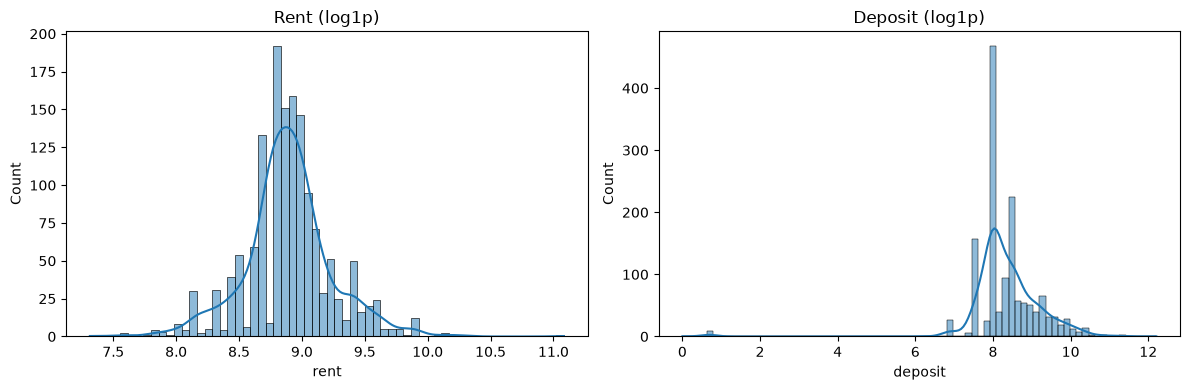

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['rent'], kde=True, ax=ax[0])
ax[0].set_title("Rent (log1p)")

sns.histplot(df['deposit'], kde=True, ax=ax[1])
ax[1].set_title("Deposit (log1p)")

plt.tight_layout()

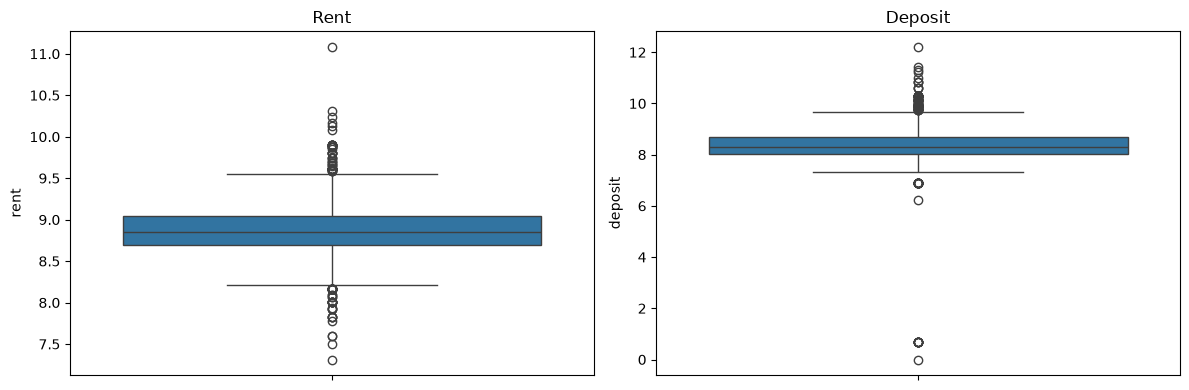

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['rent'], ax=ax[0])
ax[0].set_title("Rent")

sns.boxplot(y=df['deposit'], ax=ax[1])
ax[1].set_title("Deposit")

plt.tight_layout()

In [30]:
df.to_csv(
    r'D:\Hustle\Chennai-PG\Data\raw\chennai_pg_cleaned.csv',
    index=False
)

In [31]:
df['transit_score'].describe()

count    1471.000000
mean        7.282495
std         1.130875
min         0.100000
25%         6.300000
50%         7.800000
75%         8.000000
max         9.100000
Name: transit_score, dtype: float64